## **Statistical Analysis and Correlation**

**Goal**  
 Dive into return distributions, test statistical assumptions, and relationships between stocks

**Stocks**  
AAPL,MSFT, NVDA, META, GOOGL, SPY

**Key questions**  
- Are stock returns normally distributed?
- How correlated are these stocks, and does correlation change over time?
- Are the returns of high-performing stocks statistically significant?

In [2]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import yfinance as yf

# Load data, the same as Notebook 1
TICKERS = ['AAPL', 'MSFT', 'NVDA', 'META', 'GOOGL', 'SPY']
START   = '2020-01-01'
END     = '2025-12-31'

raw     = yf.download(TICKERS, start=START, end=END)
prices  = raw['Close'].dropna()
returns = prices.pct_change().dropna()

print(f"Shape: {returns.shape}")
print(f"Date range: {returns.index[0].date()} → {returns.index[-1].date()}")

[*********************100%***********************]  6 of 6 completed

Shape: (1506, 6)
Date range: 2020-01-03 → 2025-12-30


### **Part 1 - Distribution Analysis**
- Descriptive Statistics
- Quantile-Quantile Plots
- Shapiro-Wilk Normality Test

In [3]:
desc = returns.describe().T
desc['skewness'] = returns.skew()
desc['kurtosis'] = returns.kurtosis()

print(desc[['mean', 'std', 'skewness', 'kurtosis']].round(4))

          mean     std  skewness  kurtosis
Ticker                                    
AAPL    0.0011  0.0200    0.2840    6.7887
GOOGL   0.0012  0.0205    0.0034    3.5959
META    0.0012  0.0276   -0.1899   17.4938
MSFT    0.0009  0.0186    0.1055    7.5307
NVDA    0.0028  0.0335    0.3508    4.5129
SPY     0.0006  0.0131   -0.2653   13.0443


### Interpreting skewness and kurtosis:
Skewness < 0 → left tail is longer (more extreme negative days)  
Skewness > 0 → right tail is longer (more extreme positive days)  
Kurtosis < 0 → more normal distribution predicts than extreme events  
Kurtosis > 0 → more extreme events than normal distribution predicts  
Normal distribution has skewness = 0, excess kurtosis = 0

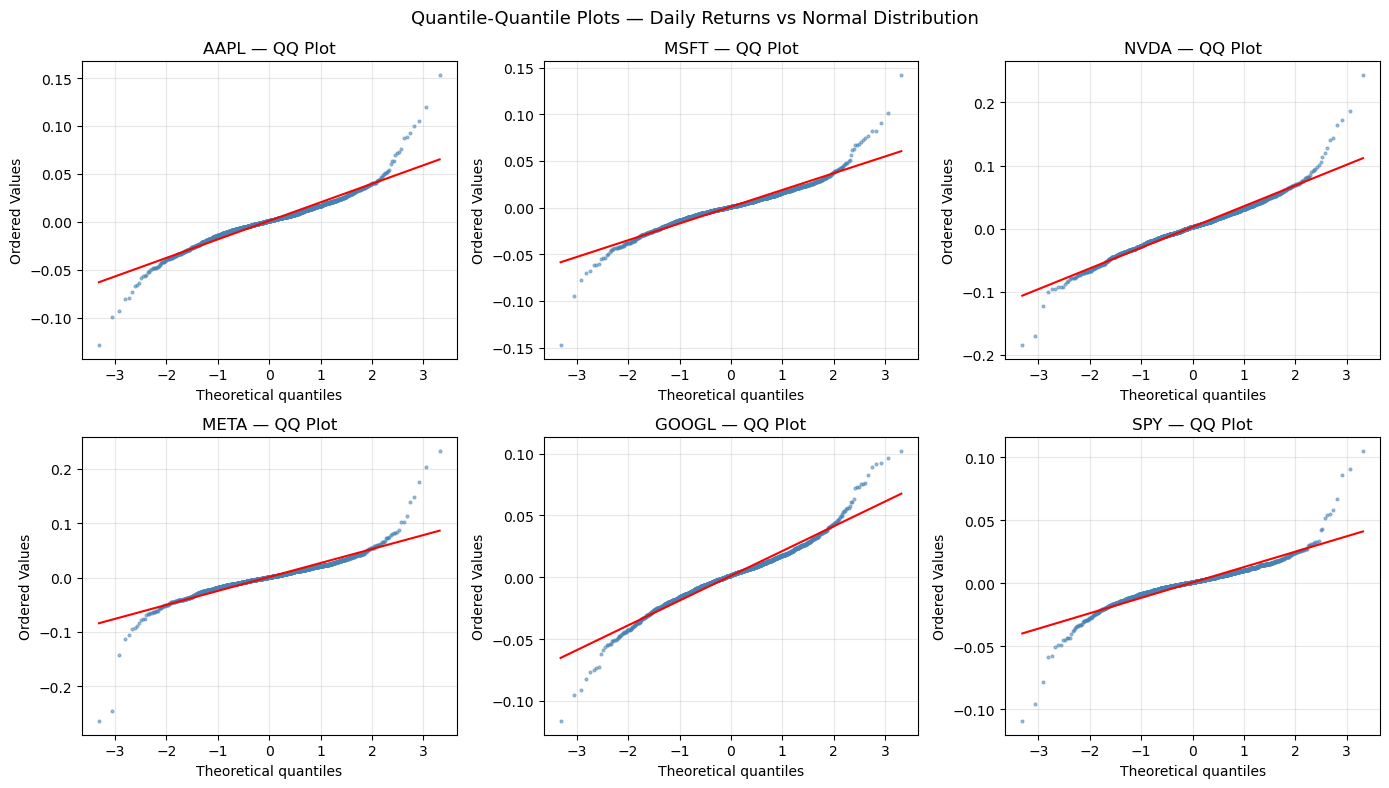

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    stats.probplot(returns[ticker].dropna(), dist="norm", plot=ax)
    ax.set_title(f'{ticker} — QQ Plot')
    ax.get_lines()[0].set(color='steelblue', markersize=2, alpha=0.5)
    ax.get_lines()[1].set(color='red', linewidth=1.5)
    ax.grid(alpha=0.3)

plt.suptitle('Quantile-Quantile Plots — Daily Returns vs Normal Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('charts/qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpreting Quantile-Quantile Plot:
Quantile-Quantile Plot compares the distribution of returns against a theoretical normal distribution.  
If returns were perfectly normal, all points would lie on the red line.

### Shapiro-Wilk Normality Test
**Hypothesis**
- Null Hypothesis: the returns are normally distributed
- Alternative Hypothesis: the returns are NOT normally distributed

In [6]:
print("Shapiro-Wilk Normality Test")
print(f"{'Ticker':<8} {'W-stat':>10} {'p-value':>12} {'Normal?':>10}")
print("-" * 45)

for ticker in TICKERS:
    sample = returns[ticker].dropna().sample(1000, random_state=42)
    stat, p = stats.shapiro(sample)
    normal = "YES" if p > 0.05 else "NO"
    print(f"{ticker:<8} {stat:>10.4f} {p:>12.6f} {normal:>10}")

Shapiro-Wilk Normality Test
Ticker       W-stat      p-value    Normal?
---------------------------------------------
AAPL         0.9243     0.000000         NO
MSFT         0.9217     0.000000         NO
NVDA         0.9656     0.000000         NO
META         0.8429     0.000000         NO
GOOGL        0.9608     0.000000         NO
SPY          0.8633     0.000000         NO


**Conclusion**  
p-value < 0.05 -> reject Null Hypothesis -> returns are not normally distributed

### **Part 2 - Correlation Analysis**
- Covariance and Correlation Matrices
- Correlation Heatmap
- Rolling Correlation

In [7]:
cov_matrix = returns.cov() * 252
corr_matrix = returns.corr()

print('Annulized Covariance Matrix:')
print(cov_matrix.round(4))
print('\nCorretation Matrix: ')
print(corr_matrix.round(4))

Annulized Covariance Matrix:
Ticker    AAPL   GOOGL    META    MSFT    NVDA     SPY
Ticker                                                
AAPL    0.1012  0.0644  0.0768  0.0667  0.0979  0.0518
GOOGL   0.0644  0.1055  0.0870  0.0672  0.0996  0.0489
META    0.0768  0.0870  0.1922  0.0808  0.1249  0.0576
MSFT    0.0667  0.0672  0.0808  0.0873  0.1062  0.0493
NVDA    0.0979  0.0996  0.1249  0.1062  0.2830  0.0775
SPY     0.0518  0.0489  0.0576  0.0493  0.0775  0.0431

Corretation Matrix: 
Ticker    AAPL   GOOGL    META    MSFT    NVDA     SPY
Ticker                                                
AAPL    1.0000  0.6231  0.5504  0.7091  0.5786  0.7839
GOOGL   0.6231  1.0000  0.6112  0.7001  0.5763  0.7254
META    0.5504  0.6112  1.0000  0.6235  0.5356  0.6328
MSFT    0.7091  0.7001  0.6235  1.0000  0.6757  0.8032
NVDA    0.5786  0.5763  0.5356  0.6757  1.0000  0.7016
SPY     0.7839  0.7254  0.6328  0.8032  0.7016  1.0000


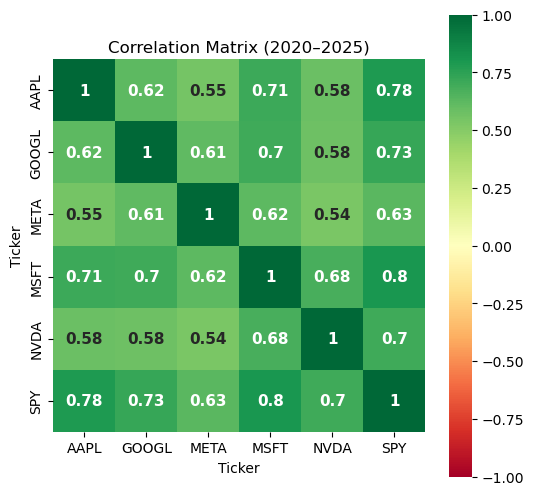

In [103]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sns.heatmap(corr_matrix,
           cmap='RdYlGn',
           vmin=-1, vmax=1,
           annot= True, square= True,
           annot_kws={'fontsize':11, 'fontweight':'bold'},)
ax.set_title('Correlation Matrix (2020–2025)')
plt.show()

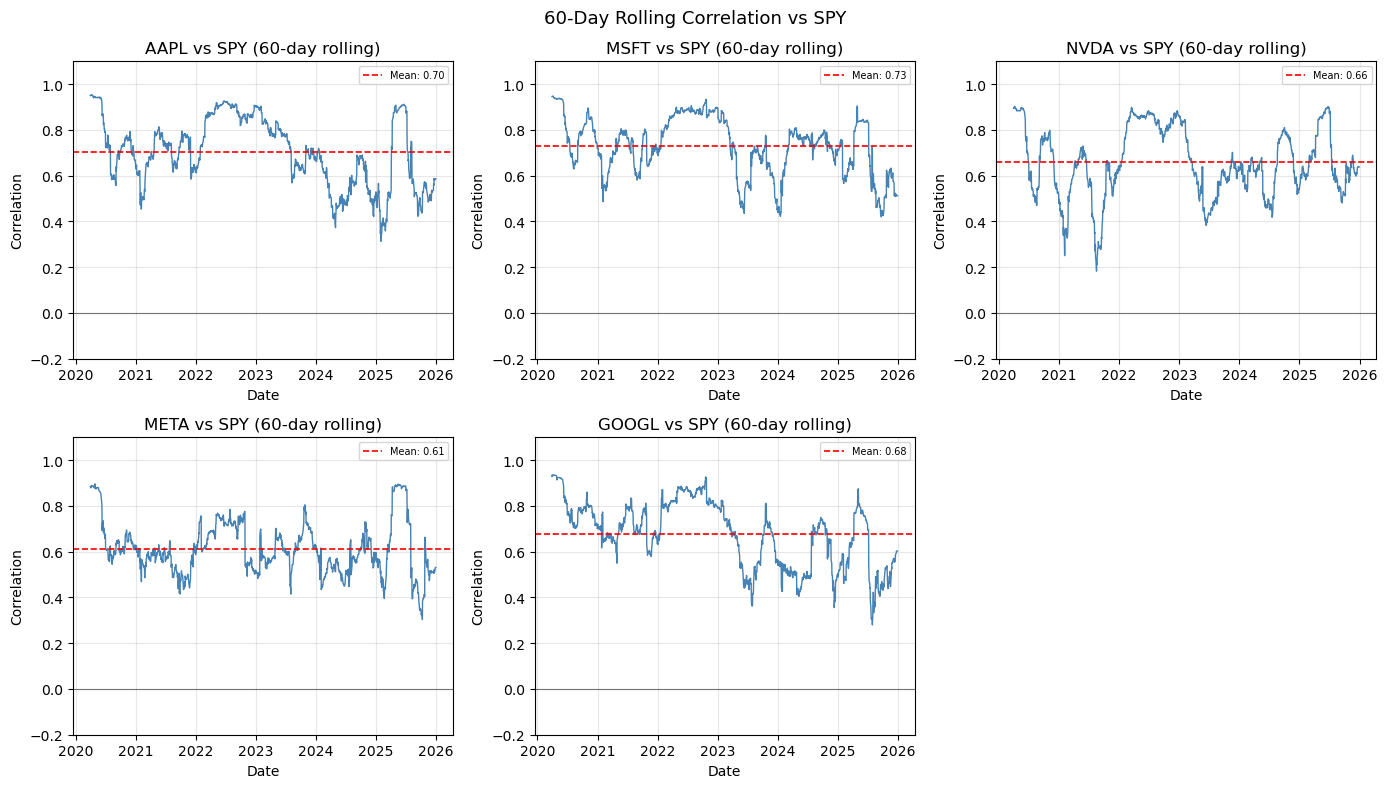

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate([t for t in TICKERS if t != 'SPY']):
    ax = axes[i]
    rolling_corr = returns[ticker].rolling(60).corr(returns['SPY'])
    
    ax.plot(rolling_corr, color='steelblue', linewidth=1.0)
    ax.axhline(rolling_corr.mean(), color='red', linestyle='--', 
               linewidth=1.2, label=f'Mean: {rolling_corr.mean():.2f}')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    
    ax.set_title(f'{ticker} vs SPY (60-day rolling)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Correlation')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.2, 1.1)

axes[-1].set_visible(False)  # hide empty 6th subplot

plt.suptitle('60-Day Rolling Correlation vs SPY', fontsize=13)
plt.tight_layout()
plt.savefig('charts/rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### Part 3 - Hypothesis Testing

**1. One-Sample t-test: Is NVDA's mean return significantly greater than 0?**  

**Hypothesis:**
- H₀: μ = 0 (mean daily return is zero — no edge)
- H₁: μ > 0 (mean daily return is positive)
- One-tailed test, significance level α = 0.05

In [9]:
print("One-Sample t-test: \nH₀: mean daily return = 0")
# alignment
print(f"{'Ticker':<8} {'Mean':>8} {'t-stat':>10} {'p-value':>12} {'Reject H₀?':>12}")
print("-" * 55)
# testing
for ticker in TICKERS:
    data = returns[ticker].dropna()
    t_stat, p_two = stats.ttest_1samp(data, popmean=0)
    p_onetail = p_two / 2
    reject = "YES" if (p_onetail < 0.05 and t_stat > 0) else "NO"
    print(f"{ticker:<8} {data.mean():>8.4f} {t_stat:>10.4f} {p_onetail:>12.6f} {reject:>12}")

One-Sample t-test: 
H₀: mean daily return = 0
Ticker       Mean     t-stat      p-value   Reject H₀?
-------------------------------------------------------
AAPL       0.0011     2.0937     0.018227          YES
MSFT       0.0009     1.9698     0.024522          YES
NVDA       0.0028     3.2988     0.000497          YES
META       0.0012     1.6260     0.052083           NO
GOOGL      0.0012     2.3253     0.010094          YES
SPY        0.0006     1.9031     0.028608          YES


**2. Two-Sample t-test: Is NVDA's return significantly higher than SPY?**  

**Hypothesis:**
- H₀: μ_NVDA = μ_SPY (no difference in mean returns)
- H₁: μ_NVDA > μ_SPY
- One-tailed Welch's t-test (does not assume equal variance)

In [10]:
print("Two-Sample t-test: H₀: mean(stock) = mean(SPY)")
print(f"{'Ticker':<8} {'Δ Mean':>10} {'t-stat':>10} {'p-value':>12} {'Reject H₀?':>12}")
print("-" * 58)

spy_returns = returns['SPY'].dropna()

for ticker in [t for t in TICKERS if t != 'SPY']:
    data = returns[ticker].dropna()
    t_stat, p_two = stats.ttest_ind(data, spy_returns, equal_var=False)
    p_one = p_two / 2
    delta = data.mean() - spy_returns.mean()
    reject = "YES" if (p_one < 0.05 and t_stat > 0) else "NO"
    print(f"{ticker:<8} {delta:>10.4f} {t_stat:>10.4f} {p_one:>12.6f} {reject:>12}")

Two-Sample t-test: H₀: mean(stock) = mean(SPY)
Ticker       Δ Mean     t-stat      p-value   Reject H₀?
----------------------------------------------------------
AAPL         0.0004     0.7141     0.237629           NO
MSFT         0.0003     0.5185     0.302090           NO
NVDA         0.0022     2.3817     0.008664          YES
META         0.0005     0.6553     0.256182           NO
GOOGL        0.0006     0.9349     0.174970           NO


### **Key Observations**

- **Normality:** All tickers rejected the Shapiro-Wilk null hypothesis (p < 0.05) — returns are **not** normally distributed. QQ plots confirm fat tails.
- **Skewness:** Most tickers show negative skew. Extreme negative days are more common than extreme positive days
- **Kurtosis:** All tickers show positive excess kurtosis — fat tails are present across the board, consistent with known equity return properties
- **Lowest correlation with SPY:** META, therefore it is the best diversifier.
- **t-test result:** NVDA's mean return is statistically significantly greater than both 0 and SPY's mean (p < 0.05), but this is in-sample and does not imply future outperformance.